# 1. 에이전트 구축 실습

이 노트북에서는 LangChain을 사용한 에이전트와 기본적인 RAG(Retrieval-Augmented Generation) 파이프라인을 구축합니다.
한국은행 업종 보고서를 데이터로 사용하여 질문에 답변하는 봇을 만듭니다.

**목표:**
1. RAG 기반 **Custom Tool**을 정의하여 Agent가 능동적으로 검색을 수행하도록 만듭니다.
2. 현재 구현의 **문제점**을 확인합니다.

이제 환경 변수를 등록해줍시다.

- 서비스를 활용하기 위해 API KEY 값이 필요합니다. 지정된 환경변수에 API KEY를 저장하면 쉽게 API를 연동할 수 있습니다.
- .env에 환경변수를 저장하고 한 번에 불러옵니다.
- .env 파일은 기본적으로 숨김파일이므로, colab에서 볼 때는 아래와 같이 눈 표시(파란색 원)를 체크해서 파일을 볼 수 있습니다.

In [ ]:
import sys
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv(override=True)

# PROJECT_ROOT를 .env에서 읽기 (없으면 현재 디렉토리)
project_root = os.getenv("PROJECT_ROOT", os.getcwd())

# 프로젝트 루트가 유효하지 않으면, 현재 위치에서 상위로 찾기
if not os.path.exists(os.path.join(project_root, "app")):
    # 상위 디렉토리 탐색
    current = os.getcwd()
    for _ in range(5):
        if os.path.exists(os.path.join(current, "app")):
            project_root = current
            break
        current = os.path.dirname(current)

# Working Directory 설정
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import app

print(f"✅ Project Root: {project_root}")
print(f"✅ Working Directory: {os.getcwd()}")

In [ ]:
# API Key 확인 (선택 사항)
if "OPENAI_API_KEY" not in os.environ:
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

## LangChain Review

## LangChain Chat LLM (Chat completion LLM) 사용하기

Chat LLM은 메시지 리스트를 입력 받아 응답을 생성하는 대화형 LLM입니다. 챗봇, 대화형 워크플로우, 대화형 RAG, 에이전트 개발 등에 적용되는 가장 보편적인 모델입니다. 데이터를 처리하려면 invoke 메서드에 메시지 목록을 전달하면 됩니다.

LangChain [Chat llm](https://python.langchain.com/docs/integrations/chat/) 객체는 다음과 같이 생성합니다.

In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5-mini", model_provider="openai", temperature=0.6)

- model : 사용할 llm 모델 명칭
- model_provider : `openai`, `anthropic`, `google_genai` 등. pip install로 [제품사 패키지 추가설치 필요](https://python.langchain.com/docs/integrations/chat/#featured-providers).
    - 예를 들어 openai의 경우 langchain-openai 설치
- temperature : 낮을 수록 일관되고 높을 수록 무작위적이고 창의적이 됩니다.

.invoke 메서드로 LLM에 프롬프트 텍스트를 전달합니다. 결과는 AIMessage 타입의 데이터입니다.

In [ ]:
ai_response = llm.invoke("안녕하세요? 당신은 어떤 모델인가요?")

(1) Response 내용 : 응답 텍스트는 content 속성에 있습니다.

In [ ]:
ai_response.content

(2) 응답 관련 메타데이터도 확인할 수 있습니다.

llm provider의 api platform에서 지원 모델과 토큰 당 가격을 확인 가능 : [openai](https://platform.openai.com/docs/pricing)

In [ ]:
ai_response.response_metadata

(3) langchain llm의 response 데이터 타입은 Message의 한 종류인 `AIMessage` 입니다.

In [ ]:
type(ai_response)

In [ ]:
ai_response

### LLM과 메시지 리스트

우리가 사용하는 ChatLLM은 대화형 데이터를 처리하기 위해 SystemMessage, HumanMessage, AIMessage, ToolMessage 객체를 사용하여 [메시지](https://python.langchain.com/docs/concepts/messages/)를 정의합니다.

In [ ]:
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

messages = [
    SystemMessage("당신은 오직 한국어로 답변하는 친절한 AI입니다. 간결하게 답변합니다."),
    HumanMessage("제 이름은 제이든입니다. 취미는 독서입니다."),
    AIMessage("안녕하세요! 제이든. 좋은 취미입니다."),
    HumanMessage("제 취미를 더 잘 즐길 수 있는 방법을 알려주세요.")
]

llm.invoke(messages)

### LangChain 에이전트

LangGraph **Agent**는 주어진 작업을 수행하기 위해 연동된 외부 도구를 호출하여 문제를 해결합니다.

LLM(언어 모델)을 기반으로 하며, 그래프 내에서 **도구(Tool or Functions)**와 상호작용하여 LLM에게 어려운 작업을 처리할 수 있습니다. LLM은 자연어 처리 능력만으로 제한적일 수 있으므로, 특정 작업(예: 데이터 검색, 계산, 파일 읽기 등)을 수행하기 위해 외부의 도구를 호출합니다.

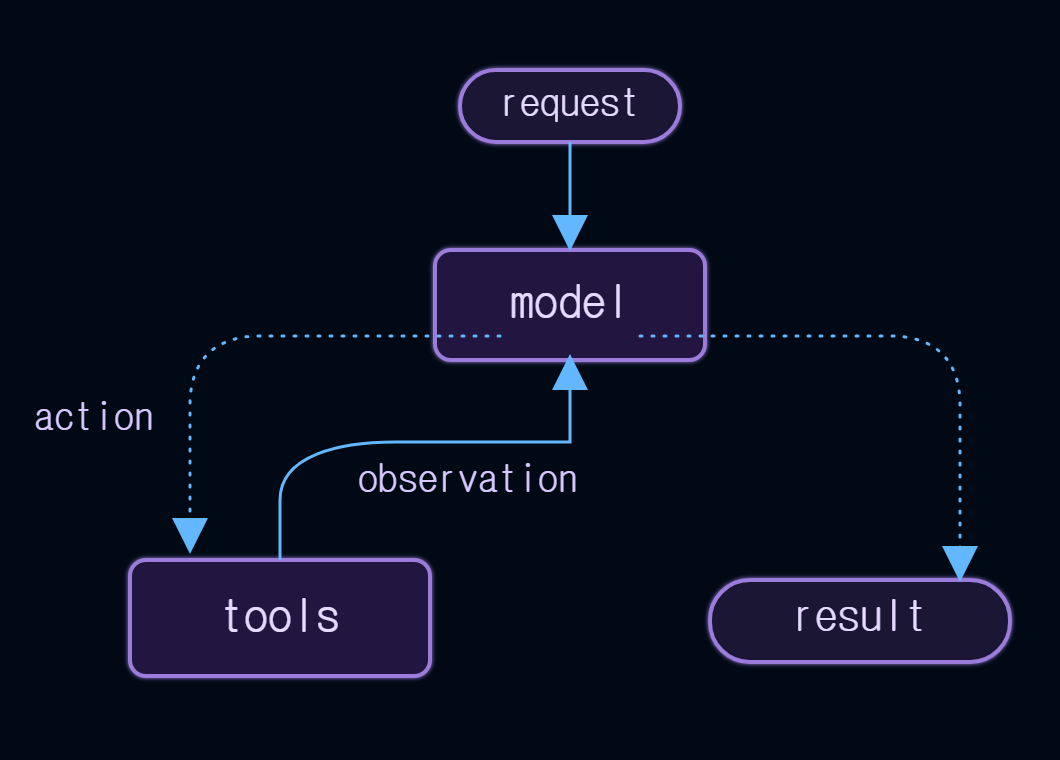

ReAct 에이전트를 생성합니다. 에이전트의 도구를 정의합니다.

LangChain Agent docs : [Link](https://docs.langchain.com/oss/python/langchain/agents)

In [ ]:
from langchain.tools import tool

@tool(parse_docstring=True)
def multiply(a: float, b: float) -> float:
    """Multiply a and b.

    Args:
        a: first float
        b: second float
    """
    return a * b


@tool(parse_docstring=True)
def add(a: float, b: float) -> float:
    """Adds a and b.

    Args:
        a: first float
        b: second float
    """
    return a + b


@tool(parse_docstring=True)
def divide(a: float, b: float) -> float:
    """Divide a and b.

    Args:
        a: first float
        b: second float
    """
    return a / b

@tool(parse_docstring=True)
def subtract(a: float, b: float) -> float:
    """subtract a and b.

    Args:
        a: first float
        b: second float
    """
    return a - b


tools = [add, multiply, divide, subtract]

for t in tools:
    print("Tool Name:", t.name)
    print("Description:", t.description)
    print("JSON Schema:", t.args)
    print("---------"*20)

create_agent은 agent의 워크플로우를 쉽게 빌드할 수 있도록 만든 langchain 함수입니다.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent


llm = init_chat_model(model="gpt-5-mini", model_provider="openai")

agent = create_agent(
    model=llm,
    tools=tools,
)

Agent에게 요청(Request)를 전달하면 tool은 순차적으로 실행되며 문제를 해결할 수 있음.

In [ ]:
from langchain_core.messages import HumanMessage

# Invoke
messages = [HumanMessage(content="도구를 사용하여 다음을 계산합니다 : 103과 439을 더한 이후 4로 나눈다.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

[실습] 에이전트 하네스 구성하기

1. 새로운 도구 추가해보세요. 예시) 에이전트가 필요 시 당신의 이름과 직업을 가져오는 도구를 정의합니다.

2. 에이전트에 시스템 프롬프트 추가합니다.

3. 에이전트 메모리 추가합니다.

## RAG Agent 구축하기

### 1. 데이터 로드 및 전처리

이제 RAG 구축을 위한 데이터를 읽어옵니다.

- 한국은행에제 RAG 구축을 위한 데이터를 읽어옵니다.

- 한국은행 [주력산업 모니터링 보고서](https://www.bok.or.kr/portal/singl/newsData/list.do?pageIndex=&targetDepth=3&menuNo=201127&syncMenuChekKey=1&depthSubMain=&subMainAt=&searchCnd=1&searchKwd=&depth2=201042&depth3=201127&date=&sdate=&edate=&sort=1&pageUnit=10)입니다.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import glob

# 데이터 경로 설정 (project_root 기반)
DATA_DIR = os.path.join(project_root, "data/bok_major_industry_reports")

# 모든 PDF 파일 경로 찾기
pdf_files = glob.glob(os.path.join(DATA_DIR, "*.pdf"))
print(f"Found {len(pdf_files)} PDF files: {pdf_files}")

docs = []
for file_path in pdf_files:
    loader = PyPDFLoader(file_path)
    docs.extend(loader.load())

print(f"Total pages loaded: {len(docs)}")

In [ ]:
# 문서 분할 (Chunking)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=200
)

docs = text_splitter.split_documents(docs)
print(f"Created {len(docs)} chunks.")

In [ ]:
# 데이터 확인
from IPython.display import display, Markdown

print("--- Sample Chunks ---")
for doc in docs[10:15]:
    display(Markdown(doc.page_content))
    print("=====================================\n\n")

### 2. Vector DB 구축 (Chroma)

임베딩 모델로는 `text-embedding-3-large`를 사용하고, Vector DB는 `Chroma`를 사용합니다.

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from IPython.display import display, Markdown

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

# 벡터 저장소 생성 (메모리 내)
report_vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory=f"{project_root}/data/chroma_db_notebooks",    
    collection_name="basic_rag"
)

report_retriever = report_vectorstore.as_retriever()

# 검색 테스트
query = "2024년 4분기 반도체 업황"
retrieved_docs = report_retriever.invoke(query)

print(f"-- Search Results for '{query}' --")
for doc in retrieved_docs:
    display(Markdown(str(doc.metadata)))
    print(doc.page_content[:200] + "...")
    print("=====================================\n\n")

### 3. Agent Tool (Custom Tool Definition)

여기서는 `create_retriever_tool` 대신 **`@tool` 데코레이터**를 사용하여 커스텀 툴을 정의합니다.
이렇게 하면:
1. `limit` 등을 인자로 받아 LLM이 검색 개수를 조절할 수 있습니다.
2. 검색 결과 포맷팅(Metadata 포함)이나 로깅을 우리가 원하는 대로 제어할 수 있습니다.

In [ ]:
from langchain_core.tools import tool

@tool(parse_docstring=True)
def search_bok_reports(query: str, limit: int = 4) -> str:
    """Search the Bank of Korea industry reports for relevant information.

    Args:
        query: The search query to find relevant information in the reports.
        limit: The maximum number of documents to retrieve. Defaults to 4.
    """
    print(f"[Tool Log] Searching for '{query}' with limit={limit}...")

    # Retriever의 'k' 값을 동적으로 조절하기 위해 search_kwargs 업데이트
    report_retriever = report_vectorstore.as_retriever()
    docs = report_retriever.invoke(query, k=limit)

    result_text = ""
    for i, doc in enumerate(docs):
        # Metadata 정보도 답변 생성에 참고할 수 있도록 포함
        meta_str = str(doc.metadata)
        result_text += f"[Document {i+1}]\nMetadata: {meta_str}\nContent: {doc.page_content}\n\n"

    return result_text

tools = [search_bok_reports]

In [ ]:
# Custom Tool 테스트 (Direct Invocation)
# 에이전트 연결 전, 도구가 잘 작동하는지 단독으로 테스트합니다.
test_query = "반도체 수출 전망"
print(f"Testing tool with query: {test_query}\n")

tool_output = search_bok_reports.invoke({"query": test_query, "limit": 2})
print(tool_output)

In [ ]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

# Agent 생성 (User-requested style)
rag_agent = create_agent("openai:gpt-4o", tools=tools)

# Agent 테스트
input_query = "24년도 2분기 반도체 업황을 핵심 위주로 요약해줘."

response = rag_agent.invoke({"messages": [("user", input_query)]})

print(f"Q: {input_query}\n")
print(f"A: {response['messages'][-1].content}")

### 4. Self-Querying Retriever (셀프 쿼리 리트리버)로 성능 개선하기

Self-Querying Retriever는 사용자의 **자연어 질문을 LLM이 직접 분석**하여, 검색에 필요한 **의미 검색용 쿼리 문자열**과 **메타데이터 필터 조건**을 **자동으로 생성**하고 이를 사용하여 벡터 저장소를 검색하는 지능적인 RAG 기법입니다. 사용자가 복잡한 필터 구문을 알 필요 없이, 일상적인 대화처럼 질문해도 정교한 필터링이 가능해집니다.

In [ ]:
import re, os
from app.utils.pymupdf4llm_loader import PyMuPDF4LLMLoader
from langchain_core.documents import Document
import glob

DATA_DIR = os.path.join(project_root, "data/bok_major_industry_reports")
pdf_files = glob.glob(os.path.join(DATA_DIR, "*.pdf"))

docs = []
for file_path in pdf_files:
    filename = os.path.basename(file_path)
    match = re.search(r"(\d{4})_(\d)사분기", filename) # 메타데이터 추출
    year = int(match.group(1)) if match else 2024
    quarter = int(match.group(2)) if match else 0
    print(f"Loading {filename} (Year={year}, Quarter={quarter})...")
    
    loader = PyMuPDF4LLMLoader(file_path, mode="page", extract_images=False)
    file_docs = loader.load()

    # 전체 일괄 병합 대신 인접 2페이지씩 슬라이딩 윈도우 병합 진행
    for i in range(len(file_docs)):
        current_doc = file_docs[i]
        current_page = current_doc.metadata.get('page', i + 1)
        
        if i < len(file_docs) - 1:
            next_doc = file_docs[i + 1]
            next_page = next_doc.metadata.get('page', i + 2)
            combined_text = current_doc.page_content + "\n\n" + next_doc.page_content
            page_range = f"{current_page}~{next_page}"
        else:
            # 마지막 페이지는 단독 처리
            combined_text = current_doc.page_content
            page_range = f"{current_page}"
            
        combined_doc = Document(
            page_content=combined_text,
            metadata={
                "year": year,
                "quarter": quarter,
                "source": filename,
                "page": page_range # 페이지 번호 범위 저장 (예: "3~4")
            }
        )
        docs.append(combined_doc)

print(f"Successfully loaded. Total combined documents: {len(docs)}")

추출한 문서를 청킹 후 벡터저장소에 저장합니다.

In [ ]:
from langchain_text_splitters import MarkdownTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.retrievers.self_query.base import SelfQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo

# 1. 텍스트 분할 (마크다운 헤더 구조 고려)
text_splitter = MarkdownTextSplitter(chunk_size=2000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)

# 2. 벡터 저장소 생성
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=OpenAIEmbeddings(model="text-embedding-3-large"),
    persist_directory=f"{project_root}/data/chroma_db_notebooks",     
    collection_name="self_query"
)
print("Vectorstore 구축 완료!")


# 3. 메타데이터 필드 정보
metadata_field_info = [
    AttributeInfo(
        name="year",
        description="해당 보고서의 연도를 나타내는 정수 값 (예: 2024)",
        type="integer",
    ),
    AttributeInfo(
        name="quarter",
        description="해당 보고서의 분기를 나타내는 숫자로 1, 2, 3, 4 중 하나.",
        type="integer",
    ),
]
document_content_description = """Bank of Korea Industry Reports
IMPORTANT: Filter values for 'year' and 'quarter' must always be integers (e.g., 2024, 1), NEVER strings (e.g., "2024", "1")."""

# 4. SelfQueryRetriever 생성
llm = ChatOpenAI(model="gpt-4o", temperature=0).with_config({"tags": ["exclude_from_stream"]})

sq_retriever = SelfQueryRetriever.from_llm(
    llm,
    vectorstore,
    document_content_description,
    metadata_field_info,
    verbose=False
)

In [ ]:
from IPython.display import display, Markdown

print("24년도 2분기 조선업 업황")
docs = sq_retriever.invoke("24년도 2분기 조선업 업황")
for doc in docs:
    display(Markdown(str(f"#{doc.metadata['year']}년, {doc.metadata['quarter']}분기")))
    print("=====================================")
print("24년도 4분기 반도체 산업 동향")
docs = sq_retriever.invoke("24년도 4분기 반도체 산업 동향")
for doc in docs:
    display(Markdown(str(f"#{doc.metadata['year']}년, {doc.metadata['quarter']}분기")))
    print("=====================================")
print("24년도 2분기 이후의 핸드폰 관련 자료")
docs = sq_retriever.invoke("24년도 2분기 이후의 핸드폰 관련 자료")
for doc in docs:
    display(Markdown(str(f"#{doc.metadata['year']}년, {doc.metadata['quarter']}분기")))
    print("=====================================")


In [ ]:
docs

### 5. Multimodal Retriever (멀티모달 리트리버)
이제 Self-Querying Retriever에 추가적으로 이미지와 텍스트를 동시에 검색할 수 있는 리트리버를 만들어보겠습니다.
> 💡 **Self-Query vs Multimodal — 코드 차이점**
> 
> 아래 데이터 로드 및 VectorStore 구축 코드는 Self-Query 섹션(섹션 4)과 구조가 거의 동일합니다. 
> **핵심 차이점**은 `PyMuPDF4LLMLoader`의 설정에 있습니다:
> - `extract_images=True` → PDF 내 그래프/도표 이미지를 함께 추출합니다.
> - `image_output_dir` → 추출된 이미지가 저장될 경로를 지정합니다.
> - `model=ChatGoogleGenerativeAI(...)` → 추출된 이미지를 설명(caption)하기 위한 멀티모달 LLM을 연결합니다.
> 
> 이렇게 하면 텍스트뿐 아니라 **이미지 설명(caption)이 문서 청크에 포함**되어, 검색 시 그래프나 도표 관련 질문에도 관련 문서가 검색됩니다.

In [ ]:
import re, os
from app.utils.pymupdf4llm_loader import PyMuPDF4LLMLoader
from langchain_openai import ChatOpenAI # [추가] OpenAI 임포트
from langchain_core.documents import Document
import glob

DATA_DIR = os.path.join(project_root, "data/bok_major_industry_reports")
pdf_files = glob.glob(os.path.join(DATA_DIR, "*.pdf"))

docs = []
for file_path in pdf_files:
    filename = os.path.basename(file_path)
    match = re.search(r"(\d{4})_(\d)사분기", filename) # 메타데이터 추출
    year = int(match.group(1)) if match else 2024
    quarter = int(match.group(2)) if match else 0
    print(f"Loading {filename} (Year={year}, Quarter={quarter})...")
    
    # OpenAI gpt-4o-mini 모델을 사용하여 병렬 이미지 분석 및 VLM 캡셔닝 진행
    loader = PyMuPDF4LLMLoader(
        file_path, 
        mode="page", 
        extract_images=True, 
        image_output_dir="./data/notebook_extracted_images",
        model=ChatOpenAI(model="gpt-4o-mini", temperature=0),
        max_workers=16 # 병렬 스레드 16개로 설정
    )
    file_docs = loader.load()

    # 인접 2페이지씩 슬라이딩 윈도우 방식으로 병합
    for i in range(len(file_docs)):
        current_doc = file_docs[i]
        current_page = current_doc.metadata.get('page', i + 1)
        
        if i < len(file_docs) - 1:
            next_doc = file_docs[i + 1]
            next_page = next_doc.metadata.get('page', i + 2)
            combined_text = current_doc.page_content + "\n\n" + next_doc.page_content
            page_range = f"{current_page}~{next_page}"
        else:
            combined_text = current_doc.page_content
            page_range = f"{current_page}"
            
        combined_doc = Document(
            page_content=combined_text,
            metadata={
                "year": year,
                "quarter": quarter,
                "source": filename,
                "page": page_range
            }
        )
        docs.append(combined_doc)

print(f"Successfully loaded and window-merged. Total documents for chunking: {len(docs)}")


In [ ]:
from langchain_text_splitters import MarkdownTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.retrievers.self_query.base import SelfQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo

# # 1. 텍스트 분할 (마크다운 헤더 구조 고려)
text_splitter = MarkdownTextSplitter(chunk_size=2000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)

# 2. 벡터 저장소 생성
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=OpenAIEmbeddings(model="text-embedding-3-large"),
    persist_directory=f"{project_root}/data/chroma_db_notebooks", 
    collection_name="multimodal"
)
print("Vectorstore 구축 완료!")

metadata_field_info = [
    AttributeInfo(
        name="year",
        description="해당 보고서의 연도를 나타내는 정수 값 (예: 2024)",
        type="integer",
    ),
    AttributeInfo(
        name="quarter",
        description="해당 보고서의 분기를 나타내는 숫자로 1, 2, 3, 4 중 하나.",
        type="integer",
    ),
]
document_content_description = """Bank of Korea Industry Reports 
IMPORTANT: Filter values for 'year' and 'quarter' must always be integers (e.g., 2024, 1), NEVER strings (e.g., "2024", "1")."""

llm = ChatOpenAI(model="gpt-4o", temperature=0).with_config({"tags": ["exclude_from_stream"]})

multimodal_retriever = SelfQueryRetriever.from_llm(
    llm,
    vectorstore,
    document_content_description,
    metadata_field_info,
    verbose=False
)

In [ ]:
len(splits)

### 멀티모달 리트리버 테스트
이제 이미지가 포함된 문서를 검색하고, 검색 결과에서 이미지 경로를 추출하여 LLM이 활용할 수 있는 형태로 가공하는 과정을 확인합니다.
아래 셀에서는:
1. `multimodal_retriever`로 **그래프/도표 관련 질문**을 검색합니다.
2. 검색된 문서에서 **마크다운 이미지 링크**(`![alt](path)`)를 정규식으로 추출합니다.
3. 추출된 이미지 경로와 텍스트를 합쳐, 멀티모달 LLM에 전달할 수 있는 딕셔너리(`context`, `images`, `source`)로 정리합니다.

In [ ]:
retrieved_docs = multimodal_retriever.invoke("24년도 1분기 반도체 수출의 증가폭 관련 그래프를 설명해줘")

In [ ]:
retrieved_docs

In [ ]:
from pathlib import Path

BASE_DIR = Path(project_root) # notebook이 보고 있는 base dir입니다.
DATA_DIR = BASE_DIR / "data" / "notebook_extracted_images" # 이미지가 저장된 dir입니다.

combined_text = []
image_paths = []

# 마크다운 이미지 링크 패턴: ![alt](path)
img_pattern = re.compile(r'!\[.*?\]\((.*?)\)')

for image_doc in retrieved_docs:
    content = image_doc.page_content

    # A. 이미지 경로 추출
    found_paths = img_pattern.findall(content)

    for path in found_paths:

        filename = os.path.basename(path) # 파일명 추출
        abs_path = DATA_DIR / filename # 절대 경로 생성 (Agent가 파일을 열 때 사용)

        # 중복 제거 및 실제 파일 존재 여부 확인 (안전장치)
        if path not in image_paths:
            if abs_path.exists():
                image_paths.append(str(abs_path))

    # B. 텍스트 누적 (페이지 정보 포함하여 LLM이 출처를 알 수 있게 함)
    page_num = image_doc.metadata.get('page', 'Unknown')
    combined_text.append(f"--- [Page {page_num}] ---\n{content}")


In [ ]:
{
    "context": "\n\n".join(combined_text), # 검색된 텍스트 전체
    "images": image_paths,                 # 추출된 이미지 경로 리스트
    "source": "한국은행 8대 업종 모니터링 보고서" # 출처 태그
}

## 정리(Summary)

이 노트북에서는 RAG Agent를 **세 가지 방식**으로 점진적으로 발전시켜 보았습니다.

| 단계 | 방식 | 특징 | 한계 |
|------|------|------|------|
| 1 | **Basic RAG** | 단순 유사도 검색으로 관련 문서 반환 | 시점/분기 등 조건 필터링 불가 |
| 2 | **Self-Query RAG** | LLM이 메타데이터(연도, 분기)를 자동 추출 → 정교한 필터링 | 텍스트 정보만 활용, 도표/그래프 분석 불가 |
| 3 | **Multimodal RAG** | 텍스트 + 이미지를 동시에 처리 → 도표/그래프 분석 가능 | 이미지 캡셔닝 비용 및 시간 증가 |

**핵심:**
- **Custom Tool**(`@tool` 데코레이터)을 사용하면 검색 로직을 세밀하게 제어할 수 있습니다.
- **Self-Query Retriever**는 사용자가 별도의 필터 구문 없이도 자연어만으로 메타데이터 기반 검색이 가능하게 합니다.
- **멀티모달 처리**를 통해 보고서 내 그래프/도표까지 검색 대상에 포함시킬 수 있습니다.

> 👉 **다음 노트북**에서는 이 에이전트들의 품질을 **정량적으로 평가**(LLM-as-Judge)하고, **LangSmith**를 활용한 Observability 실습을 진행합니다.
